# 00 · Python quick-start for quant finance

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/00_python_quickstart.ipynb)

Never written Python? Start here. Fifteen minutes and you will be able to load a dataset,
explore it and make a chart, which is everything the other notebooks build on.

**How to use a notebook:** click a grey code cell and press **Shift + Enter** to run it.
Output appears underneath. Cells run top to bottom; if something breaks, use *Runtime → Restart and run all*
(Colab) or *Kernel → Restart & Run All* (Jupyter).

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = "../data/" if Path("../data").exists() else "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/"
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


## 1. Variables, arithmetic and printing

In [2]:
price_buy = 100.0
price_sell = 112.5
dividend = 2.0
holding_period_return = (price_sell - price_buy + dividend) / price_buy
print("HPR =", holding_period_return)
print(f"HPR = {holding_period_return:.2%}")   # f-strings format numbers nicely

HPR = 0.145
HPR = 14.50%


## 2. Lists, loops and functions

In [3]:
returns = [0.05, -0.02, 0.03, 0.04, -0.01]

def geometric_mean(rs):
    growth = 1.0
    for r in rs:
        growth *= (1 + r)
    return growth ** (1 / len(rs)) - 1

print("Arithmetic mean:", sum(returns) / len(returns))
print("Geometric mean: ", round(geometric_mean(returns), 5))

Arithmetic mean: 0.018000000000000002
Geometric mean:  0.01762


## 3. NumPy: fast maths on whole arrays
No loops needed: operations apply element by element.

In [4]:
r = np.array(returns)
print("mean", r.mean(), "| std (sample)", r.std(ddof=1))
print("cumulative growth of $1:", np.cumprod(1 + r))

mean 0.018000000000000002 | std (sample) 0.031144823004794875
cumulative growth of $1: [1.05       1.029      1.05987    1.1022648  1.09124215]


## 4. pandas: load a dataset
`pd.read_csv` returns a **DataFrame**, a table with named columns.

In [5]:
df = pd.read_csv(DATA + "factor_returns.csv")
df.head()

,month,rf,mkt_excess,smb,hml,mom,stock_excess,fund_excess
0,2015-01,0.054,2.010,-2.260,-2.744,0.469,5.290,0.021
1,2015-02,0.083,-3.772,0.000,0.104,1.936,-7.403,-2.799
2,2015-03,0.085,3.927,1.261,-5.490,5.397,11.481,-2.140
3,2015-04,0.097,4.744,4.346,-4.729,-2.577,2.993,1.456
4,2015-05,0.095,-7.689,1.118,6.944,-1.364,-12.595,-4.893


In [6]:
df.describe()            # count, mean, std, min, quartiles, max for each column

,rf,mkt_excess,smb,hml,mom,stock_excess,fund_excess
count,120.0000,120.0000,120.0000,120.0000,120.0000,120.0000,120.0000
mean,0.0258,0.4403,0.0786,0.1483,0.4261,0.1134,0.6893
std,0.0376,3.3750,2.6010,3.0605,3.9445,6.6843,3.8899
min,0.0000,-7.6890,-5.8970,-7.3760,-8.3880,-17.6360,-6.9100
25%,0.0000,-1.6465,-1.7712,-1.6518,-2.2390,-4.7610,-2.0575
50%,0.0000,0.5565,0.0365,0.2030,0.5580,0.8215,0.5415
75%,0.0515,2.8758,1.6098,2.0227,2.8523,4.8880,3.1963
max,0.1260,9.9090,7.7490,8.3620,10.4500,20.6410,12.9850


## 5. Select, filter and create columns

In [7]:
print(df["stock_excess"].mean())                 # one column
down_months = df[df["mkt_excess"] < 0]            # filter rows
print("Down months:", len(down_months), "| avg stock return in them:", down_months["stock_excess"].mean().round(3))
df["stock_total"] = df["stock_excess"] + df["rf"]  # new column
df[["month", "stock_excess", "rf", "stock_total"]].head()

0.11341666666666672
Down months: 55 | avg stock return in them: -3.521


,month,stock_excess,rf,stock_total
0,2015-01,5.290,0.054,5.344
1,2015-02,-7.403,0.083,-7.320
2,2015-03,11.481,0.085,11.566
3,2015-04,2.993,0.097,3.090
4,2015-05,-12.595,0.095,-12.500


## 6. Plot

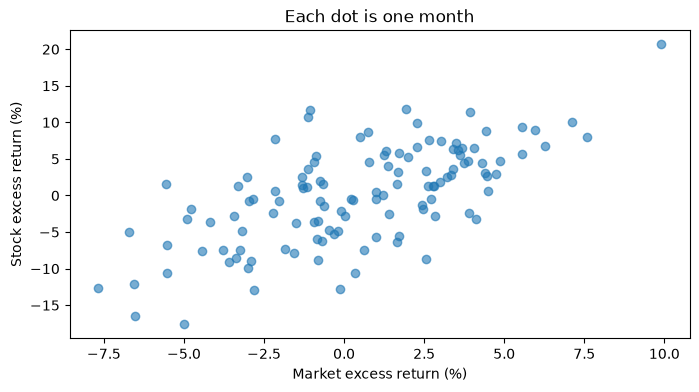

In [8]:
fig, ax = plt.subplots()
ax.scatter(df["mkt_excess"], df["stock_excess"], alpha=0.6)
ax.set_xlabel("Market excess return (%)"); ax.set_ylabel("Stock excess return (%)")
ax.set_title("Each dot is one month")
plt.show()

## 7. Correlation matrix

In [9]:
df[["mkt_excess", "smb", "hml", "mom", "stock_excess"]].corr().round(2)

,mkt_excess,smb,hml,mom,stock_excess
mkt_excess,1.00,0.07,-0.30,-0.10,0.66
smb,0.07,1.00,-0.09,-0.05,-0.01
hml,-0.30,-0.09,1.00,-0.21,-0.26
mom,-0.10,-0.05,-0.21,1.00,-0.16
stock_excess,0.66,-0.01,-0.26,-0.16,1.00


### Exercise 1

Compute the **annualised** mean (×12) and annualised standard deviation (×√12) of `mkt_excess`. Store them in `ann_mean` and `ann_std`.

<details><summary>Hint</summary>

`df['mkt_excess'].mean() * 12` and `df['mkt_excess'].std() * np.sqrt(12)`

</details>

In [10]:
# Your code here

In [11]:
check("00.1")   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 00.1: not answered yet. Store your answer in `ann_mean`, `ann_std`.


False

### Exercise 2

How many months did the stock beat the market (`stock_excess > mkt_excess`)? What fraction is that? Store them in `n_beat` and `frac_beat`.

<details><summary>Hint</summary>

A comparison gives True/False values; `.sum()` counts the Trues and `.mean()` gives the fraction.

</details>

In [12]:
# Your code here

In [13]:
check("00.2")   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 00.2: not answered yet. Store your answer in `n_beat`, `frac_beat`.


False

### Exercise 3

Load `macro_quarterly.csv` into a DataFrame called `m` and plot `inflation` over time as a line chart.

<details><summary>Hint</summary>

`m = pd.read_csv(DATA + 'macro_quarterly.csv')` then `plt.plot(m['t'], m['inflation'])`

</details>

In [14]:
# Your code here

In [15]:
check("00.3")   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 00.3: not answered yet. Store your answer in `m`.


False

---
## Solutions

Annualised mean: 5.2833000000000006 | annualised std: 11.69137316053985
Months beating market: 58 fraction: 0.483


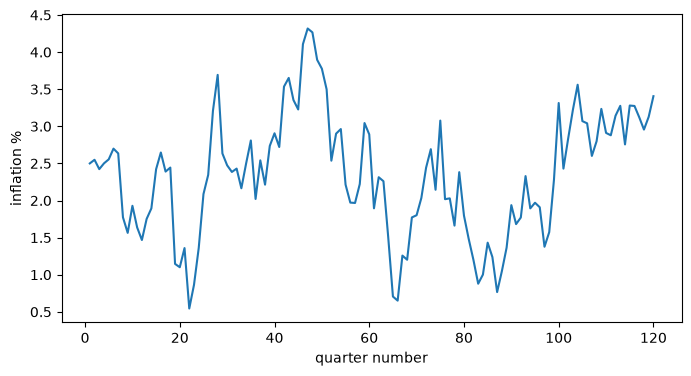

✅ Exercise 00.1: correct.
✅ Exercise 00.2: correct.
✅ Exercise 00.3: correct.

3 of 3 exercises correct.


True

In [16]:
# Exercise 1
ann_mean, ann_std = df["mkt_excess"].mean() * 12, df["mkt_excess"].std() * np.sqrt(12)
print("Annualised mean:", ann_mean, "| annualised std:", ann_std)
# Exercise 2
beat = df["stock_excess"] > df["mkt_excess"]
n_beat, frac_beat = beat.sum(), beat.mean()
print("Months beating market:", n_beat, "fraction:", round(frac_beat, 3))
# Exercise 3
m = pd.read_csv(DATA + "macro_quarterly.csv")
plt.plot(m["t"], m["inflation"]); plt.xlabel("quarter number"); plt.ylabel("inflation %"); plt.show()
check_all("00")